Zip Extracted!

Data Loaded:
         Date  Births
0  1959-01-01      35
1  1959-01-02      32
2  1959-01-03      30
3  1959-01-04      31
4  1959-01-05      44

Model Accuracy - RMSE: 7.63


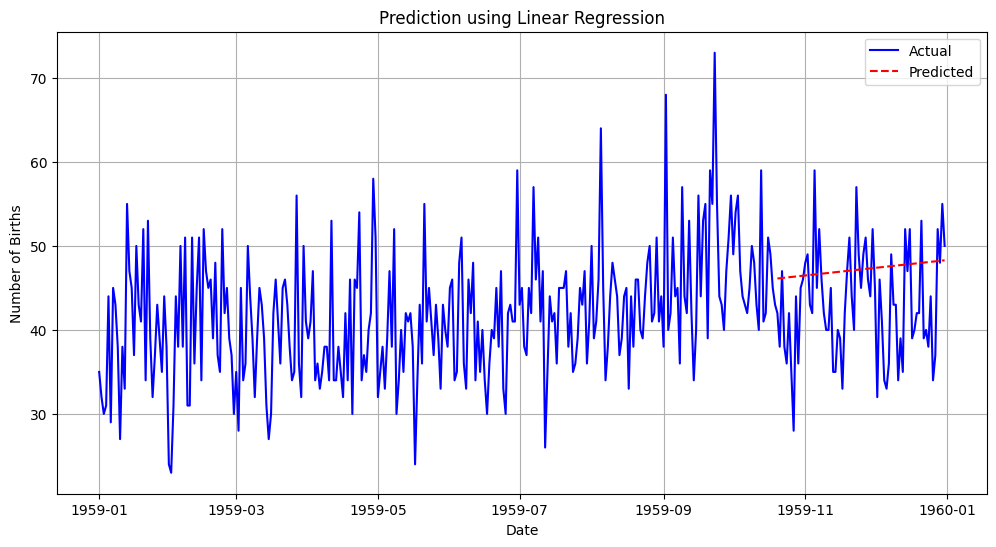


Next 7 Days Prediction:
Day 366: 48.32
Day 367: 48.35
Day 368: 48.38
Day 369: 48.41
Day 370: 48.44
Day 371: 48.47
Day 372: 48.50

DONE! Ab 'Files' tab me prediction_chart.png download kar lo


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [6]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import os

# STEP 1: ZIP EXTRACT KARO - Kyunki file already upload hai
zip_name = 'Datasets-master.zip'
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()
print("Zip Extracted!")

# STEP 2: CSV FILE LOAD KARO
csv_file = 'Datasets-master/daily-total-female-births.csv'
df = pd.read_csv(csv_file)
print("\nData Loaded:")
print(df.head())

# STEP 3: CLEANING
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# STEP 4: FEATURE BANANA
df['Day'] = np.arange(1, len(df)+1)
X = df[['Day']]
y = df['Births']

# STEP 5: TRAIN-TEST
split = int(len(df)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# STEP 6: MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# STEP 7: PREDICT + RMSE
y_pred = model.predict(X_test)
error = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nModel Accuracy - RMSE:", round(error,2))

# STEP 8: GRAPH SAVE
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Births'], label='Actual', color='blue')
plt.plot(df['Date'].iloc[X_test.index], y_pred, label='Predicted', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Number of Births')
plt.title('Prediction using Linear Regression')
plt.legend()
plt.grid(True)
plt.savefig('prediction_chart.png')
plt.show()

# STEP 9: FUTURE 7 DAYS
future_days = [[len(df)+i] for i in range(1,8)]
future_pred = model.predict(future_days)
print("\nNext 7 Days Prediction:")
for i, pred in enumerate(future_pred, 1):
    print(f"Day {len(df)+i}: {pred:.2f}")

print("\nDONE! Ab 'Files' tab me prediction_chart.png download kar lo")